# VAE hyperparameter search for cat faces - continued training (+40 epochs)

Picks up every run from `01_vae_4_hyperparam_search.ipynb` (listed in `hyperparam_search_summary.csv`), resumes each from its saved checkpoint, and trains for an additional 40 epochs (40 -> 80 total). Each continuation is written to its own new run directory so the original results are preserved.

## Imports

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from scripts import (
    DataFixedConfig,
    TrainFixedConfig,
    VAEFixedConfig,
    build_dataloaders,
    build_vae,
    compute_fid,
    count_parameters,
    output_paths,
    prepare_data,
    report_fid,
    resolve_device,
    run_name,
    save_history,
    save_history_plot,
    save_json,
    save_sample_grid,
    train_vae,
    update_total_stats,
    vae_sample_iterator,
)

## Parameters

In [2]:
# Fixed config must match 01_vae_4_hyperparam_search.ipynb exactly, since these
# values aren't stored in each run's run.json (only the grid params are) and
# the model architecture/data pipeline must match the saved checkpoints.

EXPERIMENT_NAME = "vae"

# --- Data (must match the original sweep) -------------------------------
DATA_DIR = "../data/cats-faces"
OUTPUT_DIR = "../reports/runs"
CACHE_DIR = "../.cache/fid"
IMAGE_SIZE = 64
GRAYSCALE = False
POSTERIZE_BITS = 6

# --- Model (fixed, must match the original sweep) ------------------------
HIDDEN_DIM = 512
BASE_CHANNELS = 96
AMP = True

# --- Continuation ----------------------------------------------------------
ADDITIONAL_EPOCHS = 40
SUMMARY_PATH = Path(OUTPUT_DIR) / EXPERIMENT_NAME / "hyperparam_search_summary.csv"

# --- Early stopping (restarts fresh for the continuation) -----------------
EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 0.5
EARLY_STOPPING_RESTORE_BEST = True

# --- Checkpointing -----------------------------------------------------------
SAVE_CHECKPOINT = True

# --- Logging / sampling -----------------------------------------------------
FID_REAL_SAMPLES = 5000
FID_FAKE_SAMPLES = 5000
DEVICE = "cuda"
PROGRESS_BACKEND = "terminal"

data_fixed = DataFixedConfig(
    data_dir=DATA_DIR,
    cache_dir=CACHE_DIR,
    output_dir=OUTPUT_DIR,
    image_size=IMAGE_SIZE,
    channels=1 if GRAYSCALE else 3,
    grayscale=GRAYSCALE,
    posterize_bits=POSTERIZE_BITS,
)
model_fixed = VAEFixedConfig(
    base_channels=BASE_CHANNELS,
    hidden_dim=HIDDEN_DIM,
    amp=AMP,
)
train_fixed = TrainFixedConfig(
    device=DEVICE,
    progress_backend=PROGRESS_BACKEND,
    fid_real_samples=FID_REAL_SAMPLES,
    fid_fake_samples=FID_FAKE_SAMPLES,
    early_stopping=EARLY_STOPPING,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
    early_stopping_restore_best=EARLY_STOPPING_RESTORE_BEST,
)

summary_df = pd.read_csv(SUMMARY_PATH)
print(f"Loaded {len(summary_df)} prior run(s) from {SUMMARY_PATH}")
summary_df

Loaded 12 prior run(s) from ..\reports\runs\vae\hyperparam_search_summary.csv


,run_dir,latent_dim,beta,learning_rate,epochs_run,fid,val_loss,val_reconstruction,val_kl,elapsed_seconds
0,20260613_192748_vae_z128_b0_8_lr0_001_e40,128,0.8,0.0010,40,44.882769,471.153564,378.967514,115.232560,512.428294
1,20260613_190954_vae_z128_b0_5_lr0_001_e40,128,0.5,0.0010,40,48.301246,428.806599,357.703984,142.205226,492.212235
2,20260613_193647_vae_z256_b0_5_lr0_0005_e40,256,0.5,0.0005,40,49.212697,419.126451,343.792304,150.668290,531.873360
3,20260613_200519_vae_z256_b0_8_lr0_001_e40,256,0.8,0.0010,40,49.332971,475.488050,388.524668,108.704229,539.111919
4,20260613_190126_vae_z128_b0_5_lr0_0005_e40,128,0.5,0.0005,40,50.155392,413.528815,334.892443,157.272743,488.240723
5,20260613_195535_vae_z256_b0_8_lr0_0005_e40,256,0.8,0.0005,40,50.834569,459.007832,364.724499,117.854159,554.242779
6,20260613_194602_vae_z256_b0_5_lr0_001_e40,256,0.5,0.0010,40,51.732762,432.483942,363.251235,138.465409,545.659674
7,20260613_191853_vae_z128_b0_8_lr0_0005_e40,128,0.8,0.0005,40,52.674135,452.258923,353.292680,123.707795,513.499264
8,20260613_185301_vae_z64_b0_8_lr0_001_e40,64,0.8,0.0010,40,53.110760,472.244479,383.150196,111.367855,483.981592
9,20260613_183522_vae_z64_b0_5_lr0_001_e40,64,0.5,0.0010,40,53.487353,422.247983,356.575226,131.345510,506.953580


## Data

All prior runs share the same data configuration, so it is loaded from the first run's `run.json` and prepared once for every continuation.

In [3]:
first_run_dir = summary_df.iloc[0]["run_dir"]
first_config = json.loads(
    (Path(OUTPUT_DIR) / EXPERIMENT_NAME / first_run_dir / "configs" / "run.json").read_text()
)
data_params = first_config["data"]

torch.manual_seed(data_params["seed"])
np.random.seed(data_params["seed"])

prepared = prepare_data(
    data_fixed,
    train_fraction=data_params["train_fraction"],
    validation_fraction=data_params["validation_fraction"],
    augment_flip=data_params["augment_flip"],
    seed=data_params["seed"],
)
print(f"Train images: {len(prepared.train_dataset)} | Validation: {len(prepared.validation_dataset)}")

train_loader, validation_loader = build_dataloaders(
    prepared,
    data_fixed,
    batch_size=first_config["train"]["batch_size"],
    seed=data_params["seed"],
)

device = resolve_device(train_fixed.device)
print(f"Using device: {device}")

Train images: 14172 | Validation: 1575
Using device: cuda


## Continue training

For each prior run, resumes from its checkpoint and trains for `ADDITIONAL_EPOCHS` more epochs, saving artifacts to a new run directory.

In [4]:
results = []

for i, row in summary_df.iterrows():
    prev_run_dir = row["run_dir"]
    prev_root = Path(OUTPUT_DIR) / EXPERIMENT_NAME / prev_run_dir
    prev_config = json.loads((prev_root / "configs" / "run.json").read_text())
    prev_checkpoint = prev_root / "checkpoints" / "vae_final.pt"

    model_params = dict(prev_config["model"])
    data_params = prev_config["data"]
    new_epochs = prev_config["train"]["epochs"] + ADDITIONAL_EPOCHS

    print(
        f"\n=== Run {i + 1}/{len(summary_df)}: latent_dim={model_params['latent_dim']} "
        f"beta={model_params['beta']} learning_rate={model_params['learning_rate']} "
        f"({prev_config['train']['epochs']} -> {new_epochs} epochs) ==="
    )

    run = {
        "experiment": EXPERIMENT_NAME,
        "kind": "vae",
        "data": data_params,
        "train": {**prev_config["train"], "epochs": new_epochs},
        "model": model_params,
    }

    torch.manual_seed(data_params["seed"])
    np.random.seed(data_params["seed"])

    run_dir = run_name(run["kind"], run)
    paths = output_paths(EXPERIMENT_NAME, OUTPUT_DIR, run_dir)
    save_json(paths["configs"] / "run.json", run)
    save_json(paths["configs"] / "resumed_from.json", {"run_dir": prev_run_dir})

    model = build_vae(model_params, model_fixed, data_fixed)
    print(f"VAE parameters: {count_parameters(model):,}")

    training_result = train_vae(
        model,
        train_loader,
        validation_loader,
        model_params=model_params,
        train_params=run["train"],
        train_fixed=train_fixed,
        fixed_params=model_fixed,
        sample_dir=paths["samples"],
        checkpoint_path=paths["checkpoints"] / "vae_final.pt" if SAVE_CHECKPOINT else None,
        resume_from=prev_checkpoint,
    )

    history = training_result["history"]
    save_history(history, paths["metrics"] / "history.csv")
    save_history_plot(
        history,
        paths["figures"] / "loss_curves.png",
        metrics=["loss", "validation_loss", "reconstruction", "kl"],
        title="VAE Loss Curves",
    )
    elapsed = training_result["elapsed_seconds"]
    print(f"Trained in {int(elapsed // 60):02d}:{int(elapsed % 60):02d} on {training_result['device']}.")
    update_total_stats(OUTPUT_DIR, run["kind"], run_dir, EXPERIMENT_NAME, elapsed, training_result["device"])

    with torch.no_grad():
        z = torch.randn(64, model.latent_dim, device=device)
        save_sample_grid(model.decode(z), paths["figures"] / "samples_final.png", nrow=8)

    sampler = vae_sample_iterator(
        model,
        num_samples=train_fixed.fid_fake_samples,
        batch_size=run["train"]["batch_size"],
        device=device,
        seed=data_params["seed"],
    )
    fid_start = time.perf_counter()
    fid_score = compute_fid(
        sampler,
        data_fixed,
        num_real_samples=train_fixed.fid_real_samples,
        seed=data_params["seed"],
        device=device,
    )
    fid_elapsed = time.perf_counter() - fid_start
    report_fid(fid_score, elapsed_seconds=fid_elapsed)
    save_json(paths["metrics"] / "fid.json", {"fid": fid_score, "elapsed_seconds": fid_elapsed})

    last = history[-1]
    results.append({
        "run_dir": run_dir,
        "previous_run_dir": prev_run_dir,
        "latent_dim": model_params["latent_dim"],
        "beta": model_params["beta"],
        "learning_rate": model_params["learning_rate"],
        "epochs_run": len(history),
        "fid": fid_score,
        "previous_fid": row["fid"],
        "val_loss": last["validation_loss"],
        "val_reconstruction": last["validation_reconstruction"],
        "val_kl": last["validation_kl"],
        "elapsed_seconds": elapsed,
    })

    del model
    torch.cuda.empty_cache()


=== Run 1/12: latent_dim=128 beta=0.8 learning_rate=0.001 (40 -> 80 epochs) ===
VAE parameters: 25,194,755
Using device: cuda
VAE parameters: 25,194,755
AMP enabled (fp16 autocast + GradScaler).
Resumed VAE from ..\reports\runs\vae\20260613_192748_vae_z128_b0_8_lr0_001_e40\checkpoints\vae_final.pt at epoch 40.


VAE Training: 100%|██████████| 40/40 [11:23<00:00, 17.10s/it, beta=0.800, kl=112.220, loss=324.992, val=430.751]

Restored best VAE weights from epoch 77.


Saved VAE checkpoint to ..\reports\runs\vae\20260613_223353_vae_z128_b0_8_lr0_001_e80\checkpoints\vae_final.pt.
VAE training finished in 00:11:24
Trained in 11:24 on cuda.


Generated → Inception: 79it [00:09,  8.55it/s]


...

VAE Training: 100%|██████████| 40/40 [08:32<00:00, 12.82s/it, beta=0.500, kl=132.781, loss=261.104, val=370.779]

Restored best VAE weights from epoch 79.


Saved VAE checkpoint to ..\reports\runs\vae\20260614_002934_vae_z64_b0_5_lr0_0005_e80\checkpoints\vae_final.pt.
VAE training finished in 00:08:33
Trained in 08:33 on cuda.


Generated → Inception: 79it [00:08,  8.92it/s]


FID: 60.193 (sampling took 00:00:26)


## Results

In [5]:
results_df = pd.DataFrame(results)
results_df["fid_delta"] = results_df["fid"] - results_df["previous_fid"]
results_df = results_df.sort_values("fid").reset_index(drop=True)
results_df.to_csv(Path(OUTPUT_DIR) / EXPERIMENT_NAME / "hyperparam_search_summary_02.csv", index=False)
results_df

,run_dir,previous_run_dir,latent_dim,beta,learning_rate,epochs_run,fid,previous_fid,val_loss,val_reconstruction,val_kl,elapsed_seconds,fid_delta
0,20260613_223353_vae_z128_b0_8_lr0_001_e80,20260613_192748_vae_z128_b0_8_lr0_001_e40,128,0.8,0.0010,80,42.666896,44.882769,430.751308,341.178410,111.966119,684.202251,-2.215873
1,20260613_230643_vae_z256_b0_8_lr0_001_e80,20260613_200519_vae_z256_b0_8_lr0_001_e40,256,0.8,0.0010,80,44.398845,49.332971,429.322672,341.092813,110.287326,700.541466,-4.934126
2,20260613_234127_vae_z256_b0_5_lr0_001_e80,20260613_194602_vae_z256_b0_5_lr0_001_e40,256,0.5,0.0010,80,44.725289,51.732762,392.779001,324.785257,135.987485,517.591546,-7.007473
3,20260613_224545_vae_z128_b0_5_lr0_001_e80,20260613_190954_vae_z128_b0_5_lr0_001_e40,128,0.5,0.0010,80,46.335239,48.301246,381.848365,310.909628,141.877467,646.032169,-1.966007
4,20260613_225658_vae_z256_b0_5_lr0_0005_e80,20260613_193647_vae_z256_b0_5_lr0_0005_e40,256,0.5,0.0005,80,46.953160,49.212697,372.924769,299.690981,146.467575,555.723275,-2.259538
5,20260613_235917_vae_z64_b0_8_lr0_001_e80,20260613_185301_vae_z64_b0_8_lr0_001_e40,64,0.8,0.0010,80,47.753579,53.110760,431.494488,341.476106,112.522976,625.279617,-5.357181
6,20260613_233012_vae_z256_b0_8_lr0_0005_e80,20260613_195535_vae_z256_b0_8_lr0_0005_e40,256,0.8,0.0005,80,48.592834,50.834569,412.773304,320.525469,115.309794,639.304687,-2.241735
7,20260613_231904_vae_z128_b0_5_lr0_0005_e80,20260613_190126_vae_z128_b0_5_lr0_0005_e40,128,0.5,0.0005,80,50.342613,50.155392,377.526802,303.450833,148.151941,627.443522,0.187221
8,20260613_235026_vae_z128_b0_8_lr0_0005_e80,20260613_191853_vae_z128_b0_8_lr0_0005_e40,128,0.8,0.0005,80,51.130965,52.674135,415.256895,320.034573,119.027901,509.323126,-1.543169
9,20260614_001017_vae_z64_b0_5_lr0_001_e80,20260613_183522_vae_z64_b0_5_lr0_001_e40,64,0.5,0.0010,80,51.928832,53.487353,379.002359,315.272820,127.459080,572.617257,-1.558520


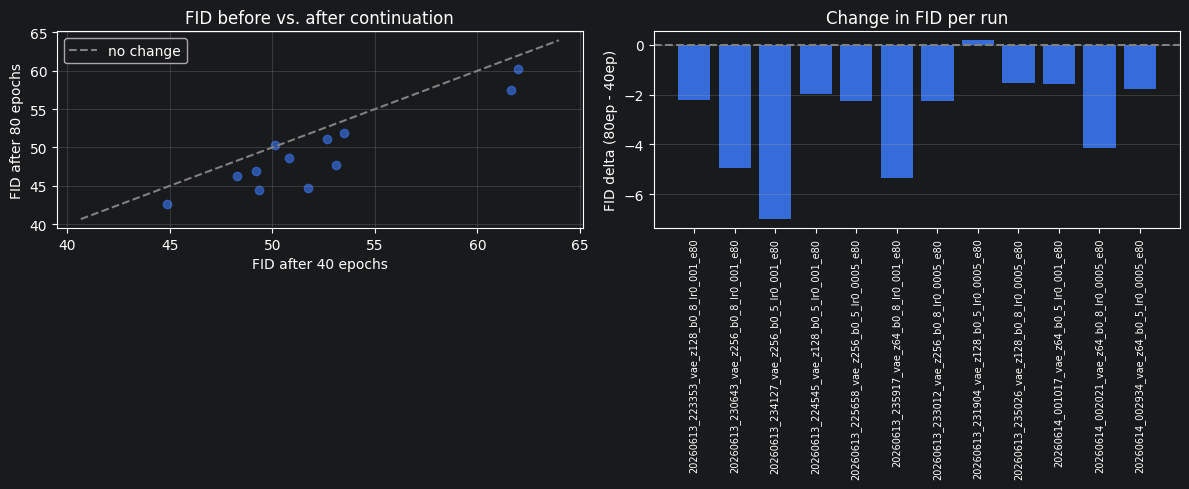

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(results_df["previous_fid"], results_df["fid"], alpha=0.7)
lims = [
    min(results_df["previous_fid"].min(), results_df["fid"].min()) - 2,
    max(results_df["previous_fid"].max(), results_df["fid"].max()) + 2,
]
axes[0].plot(lims, lims, color="gray", linestyle="--", label="no change")
axes[0].set_xlabel("FID after 40 epochs")
axes[0].set_ylabel("FID after 80 epochs")
axes[0].set_title("FID before vs. after continuation")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(results_df["run_dir"], results_df["fid_delta"])
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_ylabel("FID delta (80ep - 40ep)")
axes[1].set_title("Change in FID per run")
axes[1].tick_params(axis="x", rotation=90, labelsize=7)
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

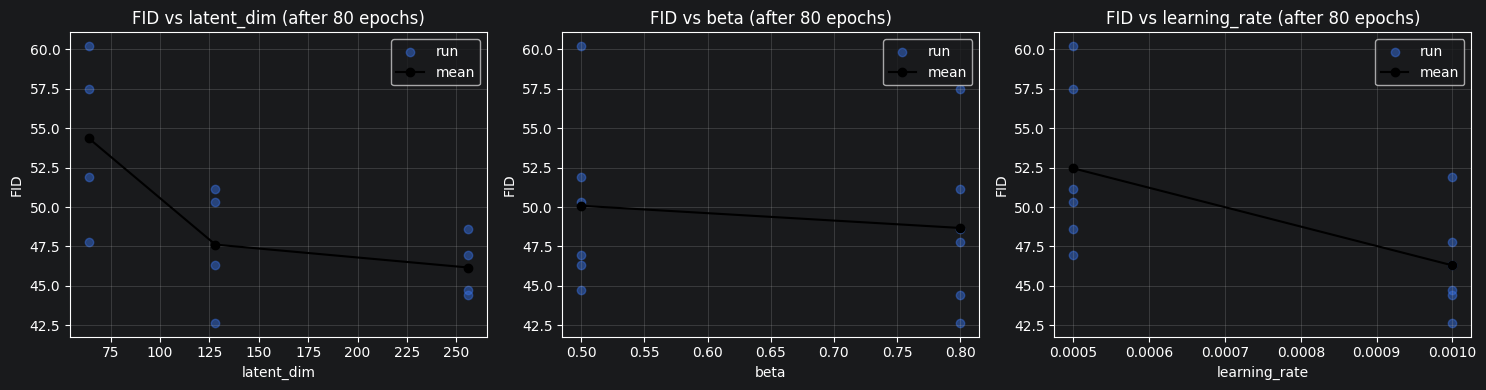

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, param in zip(axes, ["latent_dim", "beta", "learning_rate"]):
    means = results_df.groupby(param)["fid"].mean()
    ax.scatter(results_df[param], results_df["fid"], alpha=0.5, label="run")
    ax.plot(means.index, means.values, marker="o", color="black", label="mean")
    ax.set_xlabel(param)
    ax.set_ylabel("FID")
    ax.set_title(f"FID vs {param} (after 80 epochs)")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()